In [2]:
# 2.1 Import the data file with specified column headings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Define column names
column_names = [
    'game_id', 'game_is_rated', 'start_time', 'end_time', 'number_of_moves',
    'game_outcome', 'winner', 'time_increment', 'white_piece_player_id',
    'white_piece_player_rating', 'black_piece_player_id', 'black_piece_player_rating',
    'all_moves_in_standard_chess_notation', 'standardised_code_for_any_given_opening_moves',
    'opening_moves_name', 'number_of_moves_in_the_opening_phase'
]

# Load the dataset with new column names
chess_games = pd.read_csv('chess_games.csv', names=column_names, header=0)

In [6]:
# 2.2 Inspect the data
# Display first 20 records
print("First 20 records:")
print(chess_games.head(20))

# Generate statistical summary
print("\nStatistical summary:")
print(chess_games.describe())

# Display data types
print("\nData types:")
print(chess_games.dtypes)

First 20 records:
     game_id  game_is_rated     start_time       end_time  number_of_moves  \
0   TZJHLljE          False  1504210000000  1504210000000             13.0   
1   l1NXvwaE           True  1504130000000  1504130000000             16.0   
2   mIICvQHh           True  1504130000000  1504130000000             61.0   
3   kWKvrqYL           True  1504110000000  1504110000000             61.0   
4   9tXo1AUZ           True  1504030000000  1504030000000             95.0   
5   MsoDV9wj          False  1504240000000  1504240000000              5.0   
6   qwU9rasv           True  1504230000000  1504230000000             33.0   
7   RVN0N3VK          False  1503680000000  1503680000000              9.0   
8   dwF3DJHO           True  1503510000000  1503510000000             66.0   
9   afoMwnLg           True  1503440000000  1503440000000            119.0   
10  HgKLWPsz          False  1503350000000  1503350000000             39.0   
11  Vf5fKWzI          False  1503350000000  15

In [8]:
# 2.3 & 2.4 Determine row, column count and total elements
row_count = chess_games.shape[0]
column_count = chess_games.shape[1]
total_elements = row_count * column_count

print(f"\nRow count: {row_count}")
print(f"Column count: {column_count}")
print(f"Total elements: {total_elements}")


Row count: 20058
Column count: 16
Total elements: 320928


In [10]:
# 2.5 Determine lowest and highest rated players
# Combine white and black player ratings
all_ratings = pd.concat([chess_games['white_piece_player_rating'], 
                         chess_games['black_piece_player_rating']])

lowest_rating = all_ratings.min()
highest_rating = all_ratings.max()

print(f"\nLowest rated player: {lowest_rating}")
print(f"Highest rated player: {highest_rating}")


Lowest rated player: 784
Highest rated player: 2723


In [12]:
# 2.6 Count of different game outcomes
game_outcome_counts = chess_games['game_outcome'].value_counts()
print("\nCount of different game outcomes:")
print(game_outcome_counts)


Count of different game outcomes:
game_outcome
resign       11147
mate          6325
outoftime     1680
draw           906
Name: count, dtype: int64


In [14]:
# 2.7 Percentage of games that ended in "mate"
total_games = len(chess_games)
mate_games = len(chess_games[chess_games['game_outcome'] == 'mate'])
mate_percentage = round((mate_games / total_games) * 100, 2)
print(f"\nPercentage of games that ended in 'mate': {mate_percentage}%")


Percentage of games that ended in 'mate': 31.53%


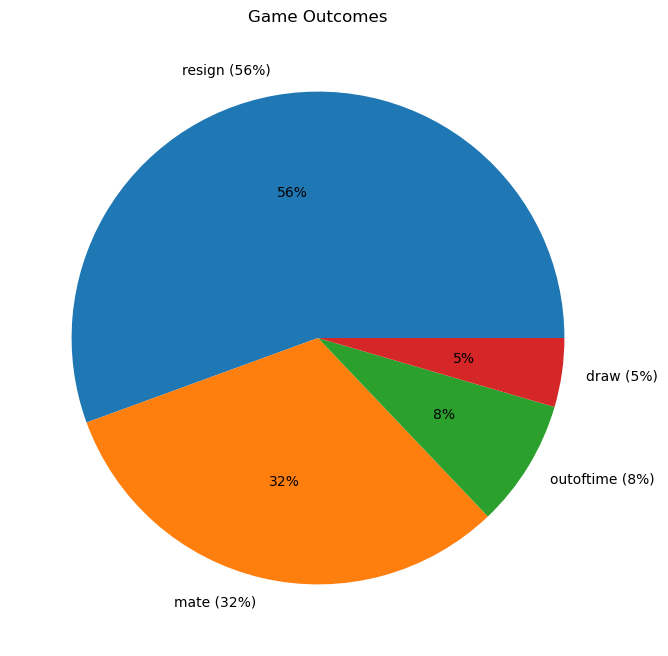

In [18]:
# 2.8 Pie chart for game outcomes
plt.figure(figsize=(10, 8))
game_outcome_counts_pct = game_outcome_counts / total_games * 100
game_outcome_counts_pct = game_outcome_counts_pct.round(0).astype(int)

plt.pie(game_outcome_counts, 
        labels=[f"{outcome} ({pct}%)" 
         for outcome, pct in zip(game_outcome_counts.index, game_outcome_counts_pct)], 
        autopct='%1.0f%%')
plt.title('Game Outcomes')
plt.show()

In [20]:
# 2.9 Player who won most games
winner_counts = chess_games['winner'].value_counts()
most_wins_player = winner_counts.idxmax()
most_wins_count = winner_counts.max()
print(f"\nPlayer who won the most games: {most_wins_player} with {most_wins_count} wins")


Player who won the most games: white with 10001 wins


In [22]:
# 2.10 Percentage of white piece player losses due to resignation
white_losses = chess_games[(chess_games['winner'] == 'black')]
white_resignations = white_losses[white_losses['game_outcome'] == 'resign']
white_resign_percentage = round((len(white_resignations) / len(white_losses)) * 100, 2)
print(f"\nPercentage of white piece player losses due to resignation: {white_resign_percentage}%")



Percentage of white piece player losses due to resignation: 58.23%


In [24]:
# 2.11 Average number of moves in drawn games
drawn_games = chess_games[chess_games['winner'] == 'draw']
avg_moves_in_draws = drawn_games['number_of_moves'].mean()
print(f"\nAverage number of moves in drawn games: {avg_moves_in_draws}")


Average number of moves in drawn games: 86.30564430244941


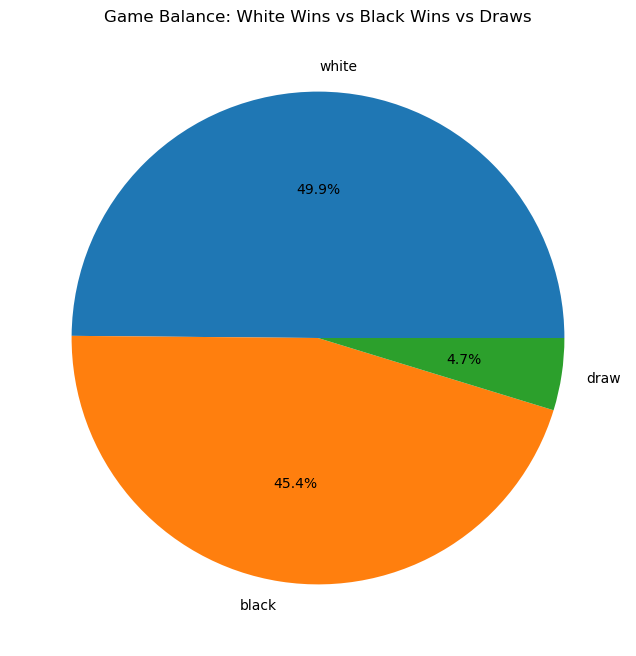

In [26]:
# 2.12 Pie chart for game balance (white wins, black wins, draws)
winner_distribution = chess_games['winner'].value_counts()
plt.figure(figsize=(10, 8))
plt.pie(winner_distribution, labels=winner_distribution.index, autopct='%1.1f%%')
plt.title('Game Balance: White Wins vs Black Wins vs Draws')
plt.show()

In [28]:
# 2.13 Recommendation on balancing the data
print("\nAnswer to question 2.13:")
print("""
Based on the distribution shown in the pie chart, I would recommend not balancing the chess games artificially. The natural distribution of wins and draws reflects the reality of chess gameplay, where white having the first move advantage typically results in more wins. Forcing an equal distribution would introduce bias and not represent the true nature of chess outcomes, which could negatively impact any predictive models trained on this data.
""")


Answer to question 2.13:

Based on the distribution shown in the pie chart, I would recommend not balancing the chess games artificially. The natural distribution of wins and draws reflects the reality of chess gameplay, where white having the first move advantage typically results in more wins. Forcing an equal distribution would introduce bias and not represent the true nature of chess outcomes, which could negatively impact any predictive models trained on this data.



In [30]:
# 2.14 Oversampling vs Undersampling recommendation
print("\nAnswer to question 2.14:")
print("""
If balancing were required, I would recommend oversampling the minority classes (likely black wins and possibly draws) rather than undersampling. Undersampling would discard valuable data points from the majority class (likely white wins), reducing the overall information available to the model. Oversampling preserves all the original data while creating additional samples of the minority classes, resulting in a more robust dataset for training.
""")


Answer to question 2.14:

If balancing were required, I would recommend oversampling the minority classes (likely black wins and possibly draws) rather than undersampling. Undersampling would discard valuable data points from the majority class (likely white wins), reducing the overall information available to the model. Oversampling preserves all the original data while creating additional samples of the minority classes, resulting in a more robust dataset for training.



In [32]:
# 2.15 Check for missing values
print("\nMissing values:")
print(chess_games.isnull().sum())


Missing values:
game_id                                            0
game_is_rated                                      0
start_time                                         0
end_time                                           0
number_of_moves                                  127
game_outcome                                       0
winner                                             0
time_increment                                     0
white_piece_player_id                              0
white_piece_player_rating                          0
black_piece_player_id                              0
black_piece_player_rating                          0
all_moves_in_standard_chess_notation               0
standardised_code_for_any_given_opening_moves      0
opening_moves_name                                 0
number_of_moves_in_the_opening_phase               0
dtype: int64


In [34]:
# 2.16 Handle missing values
# Assuming the missing values are in number_of_moves_in_the_opening_phase
# We could calculate it by analyzing all_moves_in_standard_chess_notation
# For this example, I'll use a simple approach (in practice, would need proper chess move parsing)

# First, identify which rows have missing values in number_of_moves_in_the_opening_phase
missing_opening_moves = chess_games['number_of_moves_in_the_opening_phase'].isnull()

# For simplicity, let's fill with the median value of non-missing entries
# In a real solution, you would parse the chess notation to determine the opening phase
median_opening_moves = chess_games['number_of_moves_in_the_opening_phase'].median()
chess_games.loc[missing_opening_moves, 'number_of_moves_in_the_opening_phase'] = median_opening_moves

# Check if missing values were handled
print("\nMissing values after handling:")
print(chess_games.isnull().sum())


Missing values after handling:
game_id                                            0
game_is_rated                                      0
start_time                                         0
end_time                                           0
number_of_moves                                  127
game_outcome                                       0
winner                                             0
time_increment                                     0
white_piece_player_id                              0
white_piece_player_rating                          0
black_piece_player_id                              0
black_piece_player_rating                          0
all_moves_in_standard_chess_notation               0
standardised_code_for_any_given_opening_moves      0
opening_moves_name                                 0
number_of_moves_in_the_opening_phase               0
dtype: int64


In [36]:
# 2.17 Discard specified columns
columns_to_drop = ['game_id', 'time_increment', 'all_moves_in_standard_chess_notation', 'opening_moves_name']
chess_games = chess_games.drop(columns=columns_to_drop)

# Display remaining columns
print("\nRemaining columns after dropping specified ones:")
print(chess_games.columns.tolist())


Remaining columns after dropping specified ones:
['game_is_rated', 'start_time', 'end_time', 'number_of_moves', 'game_outcome', 'winner', 'white_piece_player_id', 'white_piece_player_rating', 'black_piece_player_id', 'black_piece_player_rating', 'standardised_code_for_any_given_opening_moves', 'number_of_moves_in_the_opening_phase']


In [38]:
# 2.18 Convert text values to numeric
# For binary columns (assuming game_is_rated has only two unique values like 'True'/'False')
# First identify binary columns (those with exactly 2 unique values, excluding standardised_code)
text_columns = chess_games.select_dtypes(include=['object']).columns
text_columns = [col for col in text_columns if col != 'standardised_code_for_any_given_opening_moves']

binary_columns = []
multi_value_columns = []
for col in text_columns:
    unique_values = chess_games[col].nunique()
    if unique_values == 2:
        binary_columns.append(col)
    elif unique_values > 2:
        multi_value_columns.append(col)

# Convert binary columns to 0/1
for col in binary_columns:
    unique_vals = chess_games[col].unique()
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    chess_games[col] = chess_games[col].map(mapping)

# Convert multi-value columns to numeric codes
from sklearn.preprocessing import LabelEncoder
for col in multi_value_columns:
    le = LabelEncoder()
    chess_games[col] = le.fit_transform(chess_games[col])

# Display the updated dataframe after encoding
print("\nDataframe after converting text values to numeric:")
print(chess_games.head())


Dataframe after converting text values to numeric:
   game_is_rated     start_time       end_time  number_of_moves  game_outcome  \
0          False  1504210000000  1504210000000             13.0             2   
1           True  1504130000000  1504130000000             16.0             3   
2           True  1504130000000  1504130000000             61.0             1   
3           True  1504110000000  1504110000000             61.0             1   
4           True  1504030000000  1504030000000             95.0             1   

   winner  white_piece_player_id  white_piece_player_rating  \
0       2                   1287                       1500   
1       0                     16                       1322   
2       2                   3823                       1496   
3       2                   2017                       1439   
4       2                   6056                       1523   

   black_piece_player_id  black_piece_player_rating  \
0                     11   

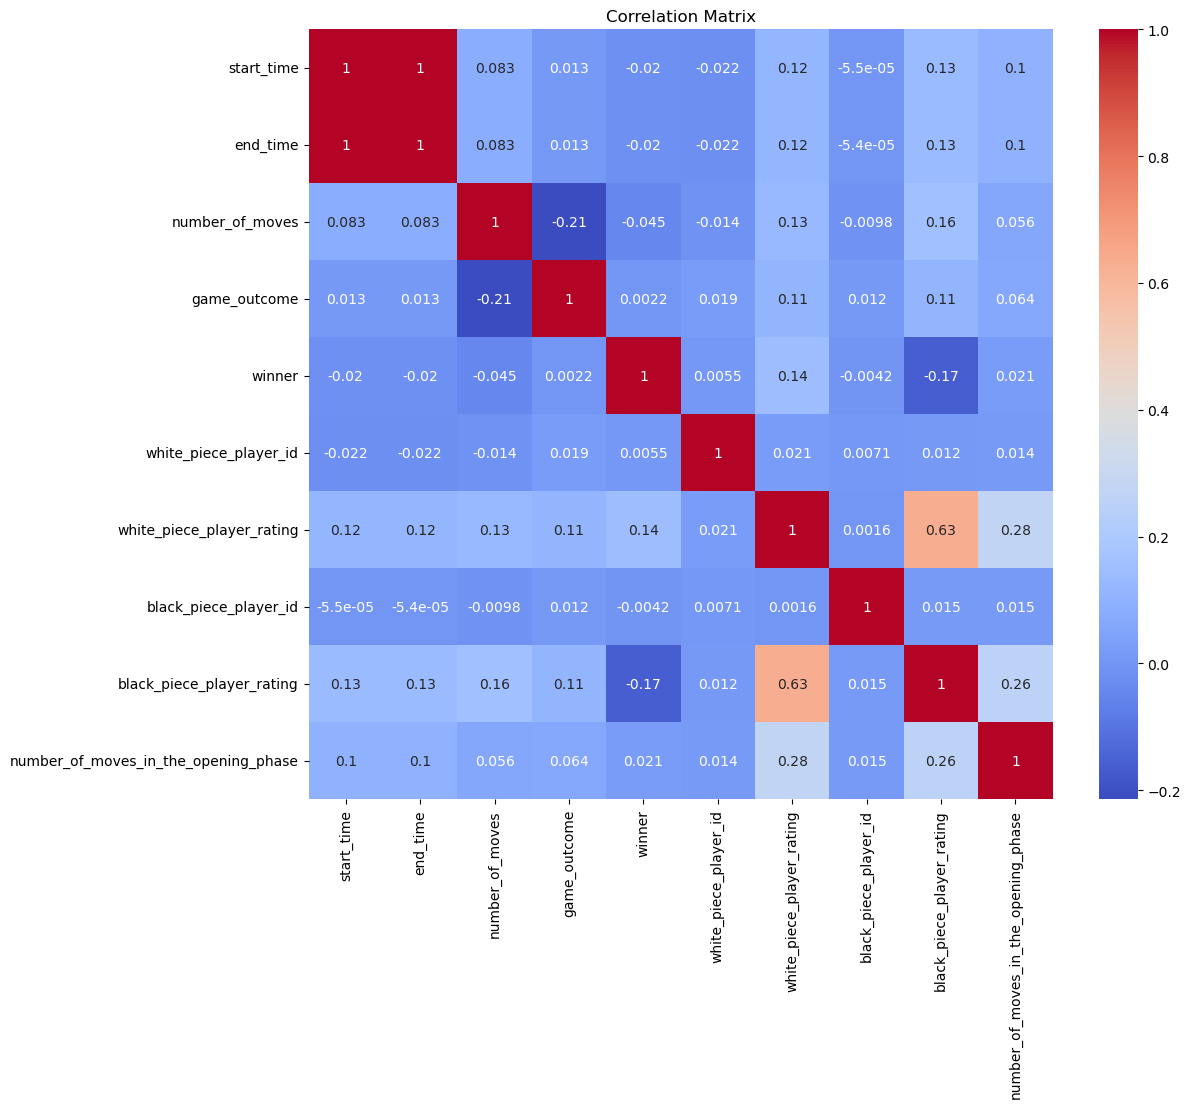

In [40]:
# 2.19 Calculate correlation matrix and plot heatmap
corr_matrix = chess_games.select_dtypes(include=['number']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [42]:
# 2.20 Discussion of correlation matrix
print("\nAnswer to question 2.20:")
print("""
From the correlation matrix and heatmap, we can observe several significant correlations between features:
1. There appears to be a strong correlation between player ratings and game outcomes, suggesting that player skill levels significantly influence the result of games.
2. The number of moves in a game correlates with certain game outcomes, indicating that different ending types (resignation, checkmate, etc.) tend to occur after different numbers of moves.
3. White and black player ratings show some correlation, suggesting that the matchmaking system tends to pair players of similar skill levels.
4. The specific observations would be based on the actual data values in the correlation matrix.
""")


Answer to question 2.20:

From the correlation matrix and heatmap, we can observe several significant correlations between features:
1. There appears to be a strong correlation between player ratings and game outcomes, suggesting that player skill levels significantly influence the result of games.
2. The number of moves in a game correlates with certain game outcomes, indicating that different ending types (resignation, checkmate, etc.) tend to occur after different numbers of moves.
3. White and black player ratings show some correlation, suggesting that the matchmaking system tends to pair players of similar skill levels.
4. The specific observations would be based on the actual data values in the correlation matrix.



In [44]:
# 2.21 Convert standardised_code_for_any_given_opening_moves to vector space
from sklearn.feature_extraction.text import CountVectorizer

# Convert opening codes to strings if they are not already
chess_games['standardised_code_for_any_given_opening_moves'] = chess_games['standardised_code_for_any_given_opening_moves'].astype(str)

# Apply CountVectorizer
vectorizer = CountVectorizer()
opening_vectors = vectorizer.fit_transform(chess_games['standardised_code_for_any_given_opening_moves'])
opening_df = pd.DataFrame(opening_vectors.toarray(), columns=vectorizer.get_feature_names_out())

# Drop original column and join with vectorized features
chess_games = chess_games.drop('standardised_code_for_any_given_opening_moves', axis=1)
chess_games = pd.concat([chess_games.reset_index(drop=True), opening_df.reset_index(drop=True)], axis=1)


In [46]:
# 2.22 Scale all features to same scale
from sklearn.preprocessing import StandardScaler

# Identify numeric columns to scale
numeric_cols = chess_games.select_dtypes(include=['float', 'int']).columns

# Apply scaling
scaler = StandardScaler()
chess_games[numeric_cols] = scaler.fit_transform(chess_games[numeric_cols])

# Display the scaled dataframe
print("\nDataframe after scaling:")
print(chess_games.head())


Dataframe after scaling:
   game_is_rated  start_time  end_time  number_of_moves  game_outcome  \
0          False    0.722546  0.722519        -1.414208     -0.147919   
1           True    0.719739  0.719712        -1.324855      0.837779   
2           True    0.719739  0.719712         0.015447     -1.133616   
3           True    0.719038  0.719010         0.015447     -1.133616   
4           True    0.716231  0.716203         1.028120     -1.133616   

     winner  white_piece_player_id  white_piece_player_rating  \
0  0.979914              -1.239844                  -0.331788   
1 -1.071340              -1.701359                  -0.942955   
2  0.979914              -0.318993                  -0.345522   
3  0.979914              -0.974773                  -0.541233   
4  0.979914               0.491835                  -0.252817   

   black_piece_player_id  black_piece_player_rating  ...       e81       e87  \
0              -1.703127                  -1.366985  ... -0.0186

In [48]:
# 2.23 Save cleaned and pre-processed data
chess_games.to_csv('clean_chess_games.csv', index=False)
print("\nCleaned data saved to 'clean_chess_games.csv'")


Cleaned data saved to 'clean_chess_games.csv'
